<a href="https://colab.research.google.com/github/sandeepa-ukr/AI-Based-Crop-Predection/blob/main/crop-recommendation-system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca_nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans_dry.csv", "beans dry"),
    ("beans_green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli_dry.csv", "chilli dry"),
    ("chilli_green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel_coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

In [3]:
crop_dfs = []

for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True)

# Remove unnecessary column
if 'Flag' in crop_df.columns:
    crop_df = crop_df.drop(columns=['Flag'])

print("Crop data shape:", crop_df.shape)
print("Unique crops:", crop_df['Item'].nunique())
print("Year range:", crop_df['Year'].min(), "-", crop_df['Year'].max())

Crop data shape: (8526, 17)
Unique crops: 49
Year range: 1965 - 2022


In [4]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

for df in [rainfall, temperature]:
    if 'YEAR' in df.columns:
        df.rename(columns={'YEAR': 'Year'}, inplace=True)

    if 'Year' not in df.columns:
        raise ValueError("Climate files must contain a 'Year' column")

In [5]:
climate_df = pd.merge(
    rainfall,
    temperature,
    on='Year',
    how='inner'
)

print("Climate data shape:", climate_df.shape)
print(climate_df['Year'].min(), "-", climate_df['Year'].max())

Climate data shape: (58, 23)
1961 - 2018


In [6]:
# Display climate data info
print("Climate Data Info:")
print(climate_df.info())
print("\nFirst 5 rows of climate data:")
print(climate_df.head())

# Check for missing values
print("\nMissing values in climate data:")
print(climate_df.isnull().sum())

# Handle missing values if any
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

# Ensure Year column is integer
climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

print(f"\nCleaned climate data shape: {climate_df_clean.shape}")

Climate Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 23 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     58 non-null     int64  
 1   JAN      58 non-null     float64
 2   FEB      58 non-null     float64
 3   MAR      58 non-null     float64
 4   APR      58 non-null     float64
 5   MAY      58 non-null     float64
 6   JUN      58 non-null     float64
 7   JUL      58 non-null     float64
 8   AUG      58 non-null     float64
 9   SEP      58 non-null     float64
 10  OCT      58 non-null     float64
 11  NOV      58 non-null     float64
 12  DEC      58 non-null     float64
 13  ANN      58 non-null     float64
 14  Jan-Feb  58 non-null     float64
 15  Mar-May  58 non-null     float64
 16  Jun-Sep  58 non-null     float64
 17  Oct-Dec  58 non-null     float64
 18  ANNUAL   58 non-null     float64
 19  JAN-FEB  58 non-null     float64
 20  MAR-MAY  58 non-null     float64
 21 

In [7]:
climate_df_clean = climate_df_clean.drop(
    columns=['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANN']
)

In [8]:
climate_df_clean

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,122.2,21.7,10.4,24.00,18.98,26.11,27.06,21.17
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,78.4,18.3,29.9,24.04,18.91,25.91,27.14,21.47
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,99.1,28.4,15.5,24.15,19.07,25.57,27.21,22.04
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,67.4,22.8,13.3,24.10,18.83,26.38,26.90,21.58
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,34.0,18.2,22.2,24.07,19.22,25.24,27.08,22.10
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,56.1,51.0,16.7,24.36,19.93,26.07,27.17,21.83
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,40.6,12.1,56.1,24.11,19.44,25.55,27.19,21.68
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,67.1,21.8,12.6,23.94,18.25,25.62,27.22,21.69
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,55.0,35.8,12.7,24.46,19.18,26.39,27.35,22.20
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,75.3,15.7,1.6,24.26,19.56,26.39,27.06,21.55


##Correlation-Based Feature Selection


Number of climate features: 16
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']


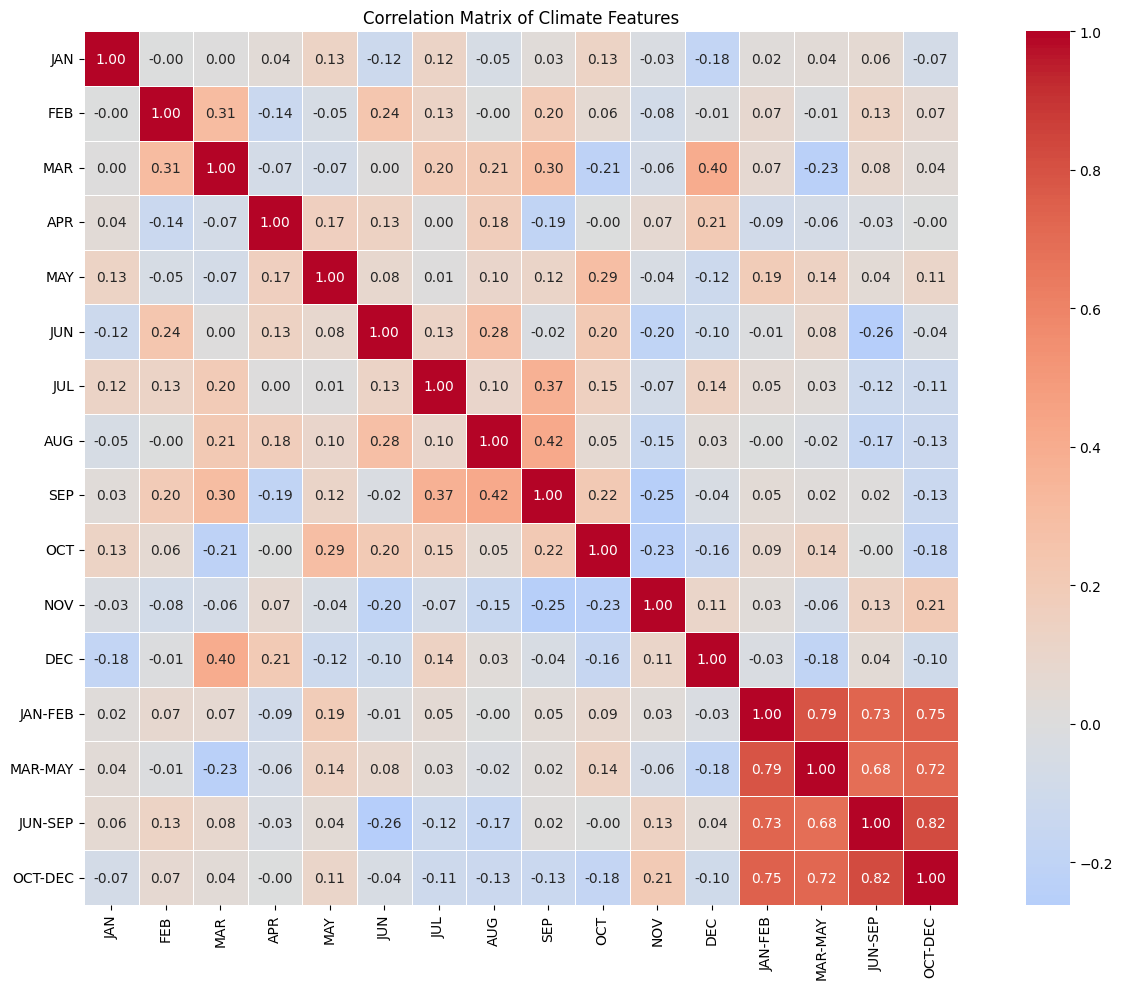


Highly correlated feature pairs (|corr| > 0.85):
No highly correlated pairs found.


In [9]:
# Separate features (exclude Year and any non-numeric columns)
feature_cols = [col for col in climate_df_clean.columns if col not in ['Year', 'ANNUAL']]
# Remove ANNUAL as it's already aggregated from other columns
feature_cols = [col for col in feature_cols if col != 'ANNUAL']

print(f"\nNumber of climate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Correlation matrix
corr_matrix = climate_df_clean[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85 or < -0.85)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated feature pairs (|corr| > {threshold}):")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())
else:
    print("No highly correlated pairs found.")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1. LOAD AND PREPARE DATA =====================
# feature_cols
# F-score selected features (from your output)
corr_selected_features = feature_cols
print(f"Correlation selected features: {corr_selected_features}")

# Load climate data with selected features
# climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()

climate_fscore = climate_df_clean[['Year'] + corr_selected_features].copy()


print("\nClimate data with correlation selected features:")
print(climate_fscore.head())
print(f"Shape: {climate_fscore.shape}")

# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")

# ===================== 2. MERGE CROP DATA WITH F-SCORE FEATURES =====================

# Merge crop data with F-score selected climate features
merged_corr_data = pd.merge(
    crop_data_clean,
    climate_fscore,
    on='Year',
    how='inner'
)

print("\nMerged dataset (crop + correlation selected features):")
print(merged_corr_data.head())
print(f"Shape: {merged_corr_data.shape}")
print(f"Columns: {merged_corr_data.columns.tolist()}")


Correlation selected features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']

Climate data with correlation selected features:
   Year   JAN   FEB   MAR   APR   MAY    JUN    JUL    AUG    SEP    OCT  \
0  1961  26.1  34.8  26.0  28.5  77.6  192.9  336.6  287.6  234.9  122.2   
1  1962  12.6  21.6  16.0  43.6  70.8  137.1  281.6  276.9  211.0   78.4   
2  1963   6.8   9.8  41.7  50.6  60.9  168.0  258.6  316.7  164.9   99.1   
3  1964  18.6  14.1  19.0  40.0  52.1  177.2  345.7  273.7  200.4   67.4   
4  1965  11.8  28.1  26.7  45.1  52.7  116.1  270.1  192.8  129.5   34.0   

    NOV   DEC  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  21.7  10.4    18.98    26.11    27.06    21.17  
1  18.3  29.9    18.91    25.91    27.14    21.47  
2  28.4  15.5    19.07    25.57    27.21    22.04  
3  22.8  13.3    18.83    26.38    26.90    21.58  
4  18.2  22.2    19.22    25.24    27.08    22.10  
Shape: (58, 17)

Crop

In [13]:
# ===================== 1. LOAD MERGED DATASET =====================

# Load the merged dataset (crop + F-score features)
merged_data = merged_corr_data

print("="*60)
print("LOADED MERGED DATASET")
print("="*60)
print(f"Dataset shape: {merged_corr_data.shape}")
print(f"Columns: {merged_corr_data.columns.tolist()}")
print("\nFirst 5 rows:")
print(merged_corr_data.head())

# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
corr_features = merged_corr_data
print(f"\nFeatures used for clustering: {corr_features}")

# Extract feature matrix
X = merged_data[corr_features].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=corr_features)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())

LOADED MERGED DATASET
Dataset shape: (7938, 23)
Columns: ['Year', 'Item', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']

First 5 rows:
   Year    Item  Value crop_type  Nitrogen (N) kg/ha  Phosphorus (P) kg/ha  \
0  1965  Apples  44500    apples               92.44                 55.16   
1  1966  Apples  38500    apples              173.10                 22.21   
2  1967  Apples  33700    apples              142.48                 58.37   
3  1968  Apples  26500    apples              123.81                 37.07   
4  1969  Apples  21700    apples               61.84                 75.57   

   Potassium (K) kg/ha   JAN   FEB   MAR  ...    JUL    AUG    SEP   OCT  \
0                43.72  11.8  28.1  26.7  ...  270.1  192.8  129.5  34.0   
1                66.33  13.1  25.4  20.3  ...  252.5  212.5  143.9  56.

ValueError: Boolean array expected for the condition, not int64